In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
import os


from extractor import get_orderbook_df, get_spot_df, get_funding_df, get_trades_df
from utils import bs_iv, bs_delta, bs_vega, bs_gamma, time_to_expiry, bs_iv_with_forward, bs_greeks, compute_greeks_df
from surface import fit_surface, svi_w, svi_iv, check_arbitrage, calibrate_heston_q, calibrate_heston_p, heston_call_fft, heston_iv_surface_fft, fit_surface, svi_iv
from model import compute_strategy_df, calibrate_lambda, arrival_probability, el_aoud_quotes
from backtest import run_backtest, compute_metrics, compare_strategies


In [3]:
# ============================================================
# CONFIG — change these for different datasets
# ============================================================

DATA_DIR = "../../RandomData"
TRADES_PATH  = "../../OptionsData/BTC-USD-optionchain-trades-2026-05.csv"


# observation window
START_DATE = '2026-05-01'
END_DATE   = '2026-05-15'
TRAIN_END  = '2026-05-11'  # first day of test period

# derive timestamps from dates
START_TS = int(pd.Timestamp(START_DATE).timestamp() * 1000)
END_TS   = int(pd.Timestamp(END_DATE + ' 23:59:59').timestamp() * 1000)

# derive days from dates
START_DAY = pd.Timestamp(START_DATE).day
END_DAY   = pd.Timestamp(END_DATE).day
DAYS      = range(START_DAY, END_DAY + 1)

# chosen expiries — inspect your data to set these based on liquidity and data availablity
EXPIRIES = ['260529', '260626', '260731', '260925']

# chosen contract - same as above
EXPIRY = '260626'
STRIKE = 80000.0
CONTRACT_TYPE = 'C'

# moneyness filter
MIN_K = -0.5
MAX_K = 0.5

# risk-free rate
r = 0.0

#risk - averse rate
EPSILON = 0.1

SVI_CACHE = '../../RandomData/svi_params_cache.parquet'
CACHE_PATH = '../../RandomData/orderbook_cache.parquet'
SVI_TEST_CACHE = '../../RandomData/svi_test_cache.parquet'


print(f"Window: {START_DATE} to {END_DATE}")
print(f"Training: {START_DATE} to {TRAIN_END}")
print(f"Test: {TRAIN_END} to {END_DATE}")
print(f"START_TS: {START_TS}")
print(f"END_TS: {END_TS}")
print(f"DAYS: {list(DAYS)}")

Window: 2026-05-01 to 2026-05-15
Training: 2026-05-01 to 2026-05-11
Test: 2026-05-11 to 2026-05-15
START_TS: 1777593600000
END_TS: 1778889599000
DAYS: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


# Loading Data

Two sources of data is assume for spot data 
1. 15 minute data corresponding to the train-test data set that we have; primarily for Q calculationss
2. 1 year of daily data of spot price; for P calculations

Orderbook data is calculated based on exchange. Pointers include:
1. Which expiries to pick depends on what makes the most sense for available data, aka is the option still valid in test data?

We also get trades data to be able to calculate order fill later.

In [4]:
# 15-minute spot — May 1-15 only (for IV computation, option pricing)
spot_15m = get_spot_df(START_TS, END_TS, bar='15m')

# daily spot — 1 year back (for P-measure CIR estimation)
ONE_YEAR_BACK = START_TS - (365 * 24 * 60 * 60 * 1000)
spot_daily = get_spot_df(ONE_YEAR_BACK, END_TS, bar='1D')

print(f"spot_15m: {spot_15m.shape} | {spot_15m['datetime'].min().date()} to {spot_15m['datetime'].max().date()}")
print(f"spot_daily: {spot_daily.shape} | {spot_daily['datetime'].min().date()} to {spot_daily['datetime'].max().date()}")

spot_15m: (1440, 3) | 2026-05-01 to 2026-05-15
spot_daily: (745, 6) | 2024-05-01 to 2026-05-15


In [5]:
if os.path.exists(CACHE_PATH):
    print("Loading from cache...")
    orderbook_raw = pd.read_parquet(CACHE_PATH)
    print(f"Loaded: {orderbook_raw.shape}")
else:
    print("Extracting from tar files (first time only, ~6 mins)...")
    orderbook_raw = get_orderbook_df(DATA_DIR, DAYS, EXPIRIES)
    orderbook_raw.to_parquet(CACHE_PATH)
    print(f"Saved to cache: {orderbook_raw.shape}")

print(f"Date range: {orderbook_raw['datetime'].min().date()} to {orderbook_raw['datetime'].max().date()}")

Loading from cache...
Loaded: (309366, 8)
Date range: 2026-05-01 to 2026-05-15


In [6]:
orderbook_df = orderbook_raw[
    orderbook_raw['datetime'] < pd.Timestamp(TRAIN_END)
].copy()

orderbook_test_df = orderbook_raw[
    orderbook_raw['datetime'] >= pd.Timestamp(TRAIN_END)
].copy()

print(f"orderbook_df (train): {orderbook_df.shape}")
print(f"orderbook_test_df:    {orderbook_test_df.shape}")

orderbook_df (train): (202595, 8)
orderbook_test_df:    (106771, 8)


In [7]:
# load all trades for lambda calibration
trades_df_all = get_trades_df(filepath=TRADES_PATH)

# load chosen contract trades separately
trades_df = get_trades_df(
    filepath=TRADES_PATH,
    expiry=EXPIRY,
    strike=STRIKE,
    contract_type=CONTRACT_TYPE
)

# training period
TRAIN_END_TS = int(pd.Timestamp(TRAIN_END).timestamp() * 1000)
trades_train_all = trades_df_all[
    trades_df_all['ts'] < TRAIN_END_TS
].copy()
trades_train = trades_df[
    trades_df['ts'] < TRAIN_END_TS
].copy()

print(f"All training trades: {len(trades_train_all)}")
print(f"Chosen contract training trades: {len(trades_train)}")
print(f"\nTop contracts by trade count:")
print(trades_train_all['instrument_name'].value_counts().head(10))

All training trades: 82039
Chosen contract training trades: 78

Top contracts by trade count:
instrument_name
BTC-USD-260731-50000-P    1062
BTC-USD-260508-83000-C     758
BTC-USD-260515-85000-C     659
BTC-USD-260508-79500-P     641
BTC-USD-260511-83000-C     603
BTC-USD-260509-78000-P     571
BTC-USD-260508-82000-C     546
BTC-USD-260508-80000-C     546
BTC-USD-260511-82500-C     543
BTC-USD-260508-79000-P     513
Name: count, dtype: int64


## Combining dataset for processing

We merge these datasets for a specific set of conditions.
To ensure that all columns are named the way they have to be, merging it with both funding and spot rate and calculating required values. 

In [8]:
# Merges the orderbook with the Spot price as well as the funding forward rate
orderbook_df = pd.merge_asof(
    orderbook_df.sort_values('ts'),
    spot_15m[['ts','close_usd']].rename(columns={'close_usd':'spot_usd'}),
    on='ts',
    direction='backward'
)

# time to expiry
from utils import time_to_expiry
orderbook_df['T'] = orderbook_df.apply(
    lambda row: time_to_expiry(row['expiry'], row['ts']), axis=1
)

# USD prices
orderbook_df['mid_usd'] = orderbook_df['mid_btc'] * orderbook_df['spot_usd']
orderbook_df['bid_usd'] = orderbook_df['best_bid_btc'] * orderbook_df['spot_usd']
orderbook_df['ask_usd'] = orderbook_df['best_ask_btc'] * orderbook_df['spot_usd']

# check spot resolution
print(f"Shape: {orderbook_df.shape}")
print(f"Unique spot values: {orderbook_df['spot_usd'].nunique()}")
print(f"Spot range: {orderbook_df['spot_usd'].min():.0f} to {orderbook_df['spot_usd'].max():.0f}")
print(orderbook_df[['datetime','spot_usd','mid_btc','mid_usd']].head(5))

Shape: (202595, 13)
Unique spot values: 939
Spot range: 76463 to 82683
                 datetime  spot_usd  mid_btc      mid_usd
0 2026-05-01 00:00:00.006   76476.2  0.54150  41411.86230
1 2026-05-01 00:00:00.006   76476.2  0.03650   2791.38130
2 2026-05-01 00:00:00.006   76476.2  0.13050   9980.14410
3 2026-05-01 00:00:00.006   76476.2  0.04425   3384.07185
4 2026-05-01 00:00:00.006   76476.2  0.11350   8680.04870


# Forward Price Using Put-Call Parity

Option pricing requires a forward price F — where the market
expects BTC to be at expiry under risk-neutral pricing.

Naively setting F = S (spot) misplaces the ATM point.
Using the perpetual funding rate gave F > S, but option
market prices implied F < S — a disconnect explained by
the difference between short-term perpetual sentiment
(8-hour funding) and longer-dated options carry (56 days).

Instead we extract F directly from put-call parity:
    F = K + (C - P)
This is model-free — no r assumption needed. The market's
implied forward is embedded in the prices it trades at.
We take the median across all strikes for robustness.

In [9]:
# ============================================================
# Section 4 — Implied Forward Price via Put-Call Parity
# ============================================================

calls = orderbook_df[orderbook_df['option_type']=='C'][
    ['ts','expiry','strike','mid_usd']
].rename(columns={'mid_usd':'call_mid'})

puts = orderbook_df[orderbook_df['option_type']=='P'][
    ['ts','expiry','strike','mid_usd']
].rename(columns={'mid_usd':'put_mid'})

cp = calls.merge(puts, on=['ts','expiry','strike'])
cp['implied_F'] = cp['strike'] + (cp['call_mid'] - cp['put_mid'])

forward_df = cp.groupby(['ts','expiry'])['implied_F'].median().reset_index()
forward_df.columns = ['ts','expiry','F']

# merge into orderbook
orderbook_df = orderbook_df.merge(forward_df, on=['ts','expiry'], how='left')

print(f"Forward price range: {orderbook_df['F'].min():.0f} to {orderbook_df['F'].max():.0f}")
print(f"Spot range:          {orderbook_df['spot_usd'].min():.0f} to {orderbook_df['spot_usd'].max():.0f}")
print(f"\nF < S on {(orderbook_df['F'] < orderbook_df['spot_usd']).mean()*100:.1f}% of observations")

Forward price range: 76320 to 83273
Spot range:          76463 to 82683

F < S on 14.8% of observations


## Log Moneyness and OTM Filter
Log moneyness k = log(K/F) measures where the strike sits
relative to the forward — the natural coordinate for the
volatility smile.

k = 0  → ATM (strike equals forward)
k < 0  → OTM put / ITM call
k > 0  → OTM call / ITM put

We restrict to |k| < 0.5 — excluding far-wing strikes
with negligible liquidity and unreliable quotes.

OTM convention: use puts below F, calls above F.
OTM options are more liquid than ITM equivalents and
numerically more stable for IV inversion (higher vega).
By put-call parity, ITM prices contain identical IV
information — using OTM avoids redundancy.

In [10]:
# log moneyness
orderbook_df['k'] = np.log(orderbook_df['strike'] / orderbook_df['F'])

# moneyness filter
orderbook_df = orderbook_df[
    (orderbook_df['k'] >= MIN_K) & 
    (orderbook_df['k'] <= MAX_K)
].copy()

# OTM filter
orderbook_df = orderbook_df[
    ((orderbook_df['strike'] >= orderbook_df['F']) & 
     (orderbook_df['option_type'] == 'C')) |
    ((orderbook_df['strike'] < orderbook_df['F']) & 
     (orderbook_df['option_type'] == 'P'))
].copy()

print(f"Shape after filters: {orderbook_df.shape}")
print(f"k range: {orderbook_df['k'].min():.3f} to {orderbook_df['k'].max():.3f}")
print(f"Puts: {(orderbook_df['option_type']=='P').sum()}")
print(f"Calls: {(orderbook_df['option_type']=='C').sum()}")

Shape after filters: (90711, 15)
k range: -0.500 to 0.500
Puts: 49985
Calls: 40726


## Implied Volatility

Convert each option's market price to implied volatility
by inverting the Black-Scholes formula.

We use bs_iv_with_forward which takes F directly —
avoiding the need to specify r separately. The forward
price from put-call parity already embeds whatever r
and carry costs the market is using.

OTM puts on the left wing, OTM calls on the right wing.
Total variance w = IV² × T is the natural SVI coordinate.


In [11]:
orderbook_df['iv'] = orderbook_df.apply(
    lambda row: bs_iv_with_forward(
        price_usd=row['mid_usd'],
        F=row['F'],
        K=row['strike'],
        T=row['T'],
        option_type=row['option_type']
    ), axis=1
)

orderbook_df['w'] = orderbook_df['iv'] ** 2 * orderbook_df['T']
orderbook_df = orderbook_df.dropna(subset=['iv']).copy()

print(f"Shape: {orderbook_df.shape}")
print(f"IV range: {orderbook_df['iv'].min():.3f} to {orderbook_df['iv'].max():.3f}")
print(f"Failed inversions: {orderbook_df['iv'].isna().sum()}")

Shape: (90711, 17)
IV range: 0.276 to 1.309
Failed inversions: 0


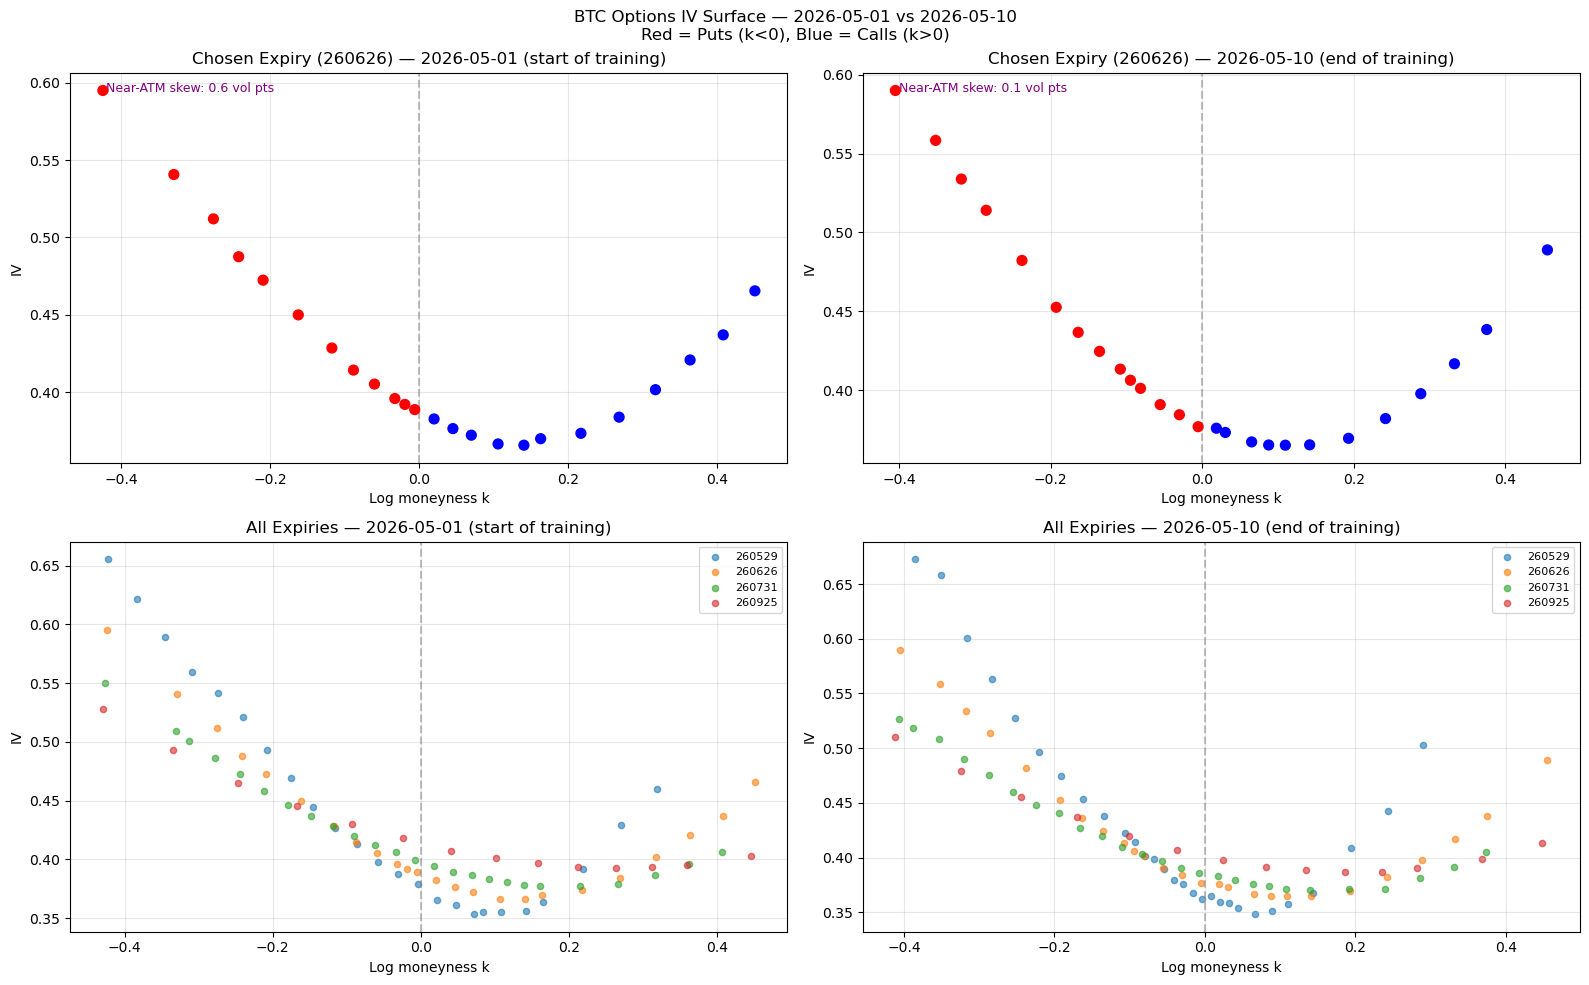

Near-ATM skew summary:

2026-05-01 (start of training):
  Last put:   k=-0.006, IV=0.389
  First call: k=0.020, IV=0.383
  Near-ATM skew: 0.6 vol points

2026-05-10 (end of training):
  Last put:   k=-0.005, IV=0.377
  First call: k=0.019, IV=0.376
  Near-ATM skew: 0.1 vol points


In [12]:
# Plot raw IV smile — start and end of training period

# first and last training timestamps
ts_start = orderbook_df[
    orderbook_df['datetime'] < pd.Timestamp(START_DATE) + pd.Timedelta(days=1)
]['ts'].min()

ts_end = orderbook_df[
    orderbook_df['datetime'] < pd.Timestamp(TRAIN_END)
]['ts'].max()

timestamps = {
    f'{START_DATE} (start of training)': ts_start,
    f'{pd.Timestamp(TRAIN_END) - pd.Timedelta(days=1):%Y-%m-%d} (end of training)': ts_end
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (label, ts) in enumerate(timestamps.items()):
    
    # top row — chosen expiry only
    s_chosen = orderbook_df[
        (orderbook_df['ts'] == ts) &
        (orderbook_df['expiry'] == EXPIRY)
    ].sort_values('k')
    
    axes[0][col].scatter(
        s_chosen['k'], s_chosen['iv'],
        c=s_chosen['option_type'].map({'C':'blue','P':'red'}),
        s=50, zorder=5
    )
    axes[0][col].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[0][col].set_title(f'Chosen Expiry ({EXPIRY}) — {label}')
    axes[0][col].set_xlabel('Log moneyness k')
    axes[0][col].set_ylabel('IV')
    axes[0][col].grid(True, alpha=0.3)
    
    # annotate near-ATM skew
    puts = s_chosen[s_chosen['option_type']=='P']
    calls = s_chosen[s_chosen['option_type']=='C']
    if len(puts) > 0 and len(calls) > 0:
        skew = (puts.iloc[-1]['iv'] - calls.iloc[0]['iv']) * 100
        axes[0][col].annotate(
            f'Near-ATM skew: {skew:.1f} vol pts',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=9, color='purple'
        )
    
    # bottom row — all expiries together
    for expiry in EXPIRIES:
        s = orderbook_df[
            (orderbook_df['ts'] == ts) &
            (orderbook_df['expiry'] == expiry)
        ].sort_values('k')
        if not s.empty:
            axes[1][col].scatter(
                s['k'], s['iv'],
                s=20, alpha=0.6, label=expiry
            )
    
    axes[1][col].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1][col].set_title(f'All Expiries — {label}')
    axes[1][col].set_xlabel('Log moneyness k')
    axes[1][col].set_ylabel('IV')
    axes[1][col].legend(fontsize=8)
    axes[1][col].grid(True, alpha=0.3)

plt.suptitle(
    f'BTC Options IV Surface — {START_DATE} vs {pd.Timestamp(TRAIN_END) - pd.Timedelta(days=1):%Y-%m-%d}\n'
    'Red = Puts (k<0), Blue = Calls (k>0)',
    fontsize=12
)
plt.tight_layout()
plt.show()

# print skew summary for both timestamps
print("Near-ATM skew summary:")
for label, ts in timestamps.items():
    s = orderbook_df[
        (orderbook_df['ts'] == ts) &
        (orderbook_df['expiry'] == EXPIRY)
    ].sort_values('k')
    puts = s[s['option_type']=='P']
    calls = s[s['option_type']=='C']
    if len(puts) > 0 and len(calls) > 0:
        last_put = puts.iloc[-1]
        first_call = calls.iloc[0]
        skew = (last_put['iv'] - first_call['iv']) * 100
        print(f"\n{label}:")
        print(f"  Last put:   k={last_put['k']:.3f}, IV={last_put['iv']:.3f}")
        print(f"  First call: k={first_call['k']:.3f}, IV={first_call['iv']:.3f}")
        print(f"  Near-ATM skew: {skew:.1f} vol points")

## SVI Calibration

The raw IV surface provides discrete, noisy observations at traded strikes. 
Before calibrating the Heston model, we fit the Stochastic Volatility Inspired 
(SVI) parametric model to each (timestamp, expiry) slice — producing a smooth, 
continuous, arbitrage-free surface that can be evaluated at any strike.

The SVI formula represents total implied variance w = IV² × T as a function 
of log moneyness k:

    w(k) = a + b(ρ(k-m) + √((k-m)² + σ²))

Five parameters control the smile shape:
- a: overall variance level
- b: wing slope (how fast IV rises away from ATM)
- ρ: skew/asymmetry (negative → puts more expensive than calls)  
- m: horizontal shift of the minimum
- σ: curvature/roundedness at ATM

We fit using L-BFGS-B optimization with multiple starting points, weighted 
to emphasize near-ATM strikes where our chosen contract sits.

The surface is verified to be arbitrage-free via butterfly and calendar checks.

In [13]:
if os.path.exists(SVI_CACHE):
    print("Loading SVI params from cache...")
    svi_params_all = pd.read_parquet(SVI_CACHE)
else:
    print("Fitting SVI...")
    svi_params_all = fit_surface(orderbook_df)
    svi_params_all.to_parquet(SVI_CACHE)
    
print(f"SVI params shape: {svi_params_all.shape}")

print(f"Shape: {svi_params_all.shape}")
print(f"Failed: {orderbook_df.groupby(['ts','expiry']).ngroups - len(svi_params_all)}")

# check residuals on May 10 last timestamp
last_train_ts = orderbook_df[
    orderbook_df['datetime'] < TRAIN_END
]['ts'].max()

params_row = svi_params_all[
    (svi_params_all['ts'] == last_train_ts) &
    (svi_params_all['expiry'] == EXPIRY)
].iloc[0]

params = {
    'split': False,
    'a': params_row['a'], 'b': params_row['b'],
    'rho': params_row['rho'], 'm': params_row['m'],
    'sigma': params_row['sigma']
}
T = params_row['T']

slice_df = orderbook_df[
    (orderbook_df['ts'] == last_train_ts) &
    (orderbook_df['expiry'] == EXPIRY)
].sort_values('k')

residuals = slice_df.apply(
    lambda row: svi_iv(row['k'], T, params) - row['iv'], axis=1
)
print(f"Max residual: {residuals.abs().max():.4f}")
print(f"RMSE: {np.sqrt((residuals**2).mean()):.4f}")

Loading SVI params from cache...
SVI params shape: (3840, 11)
Shape: (3840, 11)
Failed: 0
Max residual: 0.0046
RMSE: 0.0025


## Arbitrage Checks

Standard arbitrage checks of butterfly violations and calendar violations

In [14]:
from surface import check_arbitrage

arb_df = check_arbitrage(svi_params_all)

print(f"Butterfly violations: {(~arb_df['butterfly_ok']).sum()}")
print(f"Wing violations: {(~arb_df['wing_ok']).sum()}")

calendar_rows = arb_df.dropna(subset=['calendar_ok_vs_next'])
print(f"Calendar violations: {(~calendar_rows['calendar_ok_vs_next']).sum()}")

Butterfly violations: 0
Wing violations: 0
Calendar violations: True


In [15]:
violations = calendar_rows[calendar_rows['calendar_ok_vs_next'] == False]

print(f"Violations: {len(violations)}")
print(f"\nBy expiry:")
print(violations['expiry'].value_counts())

violations['date'] = pd.to_datetime(violations['ts'], unit='ms').dt.date
print(f"\nBy date:")
print(violations['date'].value_counts().sort_index())

Violations: 125

By expiry:
expiry
260529    123
260626      2
Name: count, dtype: int64

By date:
date
2026-05-01     4
2026-05-03     1
2026-05-05     4
2026-05-06    16
2026-05-07    47
2026-05-08    31
2026-05-09    10
2026-05-10    12
Name: count, dtype: int64


/var/folders/rq/dq8_spf15q96_fxp3m4ggdjh0000gn/T/ipykernel_74694/1131159547.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  violations['date'] = pd.to_datetime(violations['ts'], unit='ms').dt.date


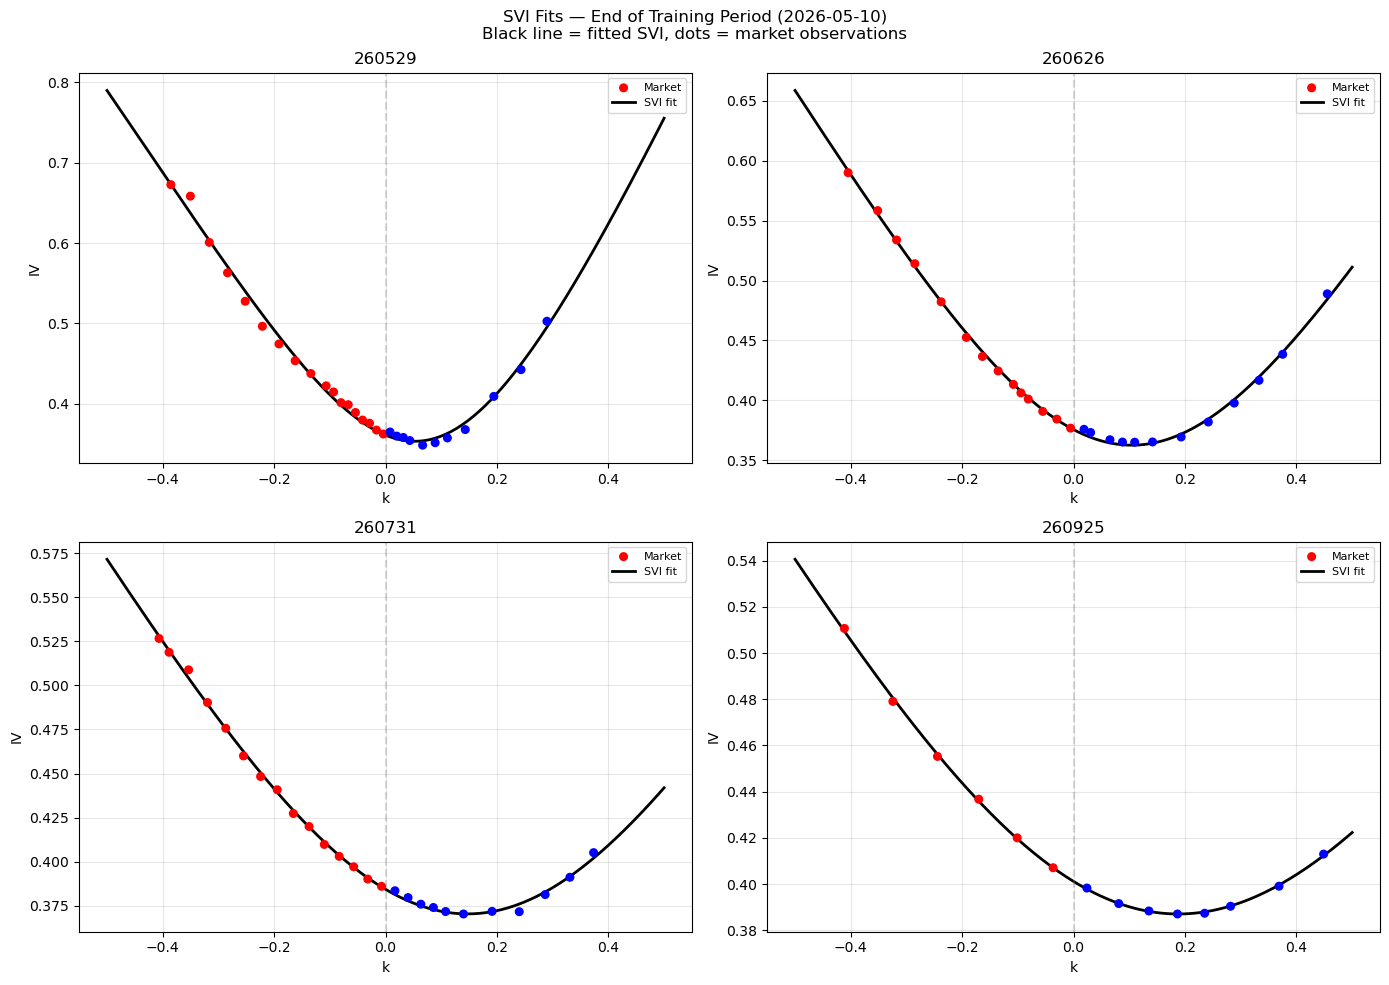

In [16]:
# plot SVI fit vs market at end of training period
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, expiry in zip(axes.flatten(), EXPIRIES):
    params_row = svi_params_all[
        (svi_params_all['ts'] == last_train_ts) &
        (svi_params_all['expiry'] == expiry)
    ]
    
    if params_row.empty:
        continue
    
    params_row = params_row.iloc[0]
    params = {
        'split': False,
        'a': params_row['a'], 'b': params_row['b'],
        'rho': params_row['rho'], 'm': params_row['m'],
        'sigma': params_row['sigma']
    }
    T = params_row['T']
    
    slice_df = orderbook_df[
        (orderbook_df['ts'] == last_train_ts) &
        (orderbook_df['expiry'] == expiry)
    ].sort_values('k')
    
    k_grid = np.linspace(MIN_K, MAX_K, 200)
    iv_fitted = [svi_iv(k, T, params) for k in k_grid]
    
    ax.scatter(slice_df['k'], slice_df['iv'],
               c=slice_df['option_type'].map({'C':'blue','P':'red'}),
               s=30, zorder=5, label='Market')
    ax.plot(k_grid, iv_fitted, 'k-', linewidth=2, label='SVI fit')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_title(f'{expiry}')
    ax.set_xlabel('k')
    ax.set_ylabel('IV')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'SVI Fits — End of Training Period ({pd.to_datetime(last_train_ts, unit="ms").date()})\n'
    'Black line = fitted SVI, dots = market observations',
    fontsize=12
)
plt.tight_layout()
plt.show()

## Heston Calibration

With a clean, arbitrage-checked SVI surface in hand, we calibrate the Heston 
stochastic volatility model under two separate probability measures.

The Heston model replaces Black-Scholes' constant volatility with a 
mean-reverting variance process:

    dS_t = μ S_t dt + √v_t S_t dW_t^(1)
    dv_t = k(θ - v_t)dt + η√v_t dW_t^(2)

with correlation dW^(1)dW^(2) = ρ dt.

The same equations hold under both measures — only the parameter values differ:

**Q-measure (market-implied):** parameters calibrated to the SVI surface at 
the end of the training period (May 10). These reflect what the market is 
collectively pricing in — including risk premia, fear of crashes, and 
supply/demand for options.

**P-measure (real-world):** parameters estimated from one year of daily BTC 
returns via OLS on the discretized CIR process. These reflect what actually 
happened historically — no risk premium, no fear, just realized dynamics.

The gap between Q and P parameters generates M₀ = C_Q - C_P — the mispricing 
signal that drives the El Aoud market making strategy.

In [17]:
# ============================================================
# Heston Q calibration — to last training timestamp surface
# ============================================================

from surface import calibrate_heston_q

# use last training timestamp
last_train_ts = orderbook_df[
    orderbook_df['datetime'] < pd.Timestamp(TRAIN_END)
]['ts'].max()

last_train_svi = svi_params_all[
    svi_params_all['ts'] == last_train_ts
]

last_train_obs = orderbook_df[
    orderbook_df['ts'] == last_train_ts
]

S_last = spot_15m[
    spot_15m['ts'] <= last_train_ts
]['close_usd'].iloc[-1]

print(f"Calibrating Q to: {pd.to_datetime(last_train_ts, unit='ms')}")
print(f"Spot: ${S_last:.0f}")
print(f"Expiries in surface: {last_train_svi['expiry'].tolist()}")

heston_q = calibrate_heston_q(
    svi_params_df=last_train_svi,
    orderbook_df=last_train_obs,
    S0=S_last,
    r=0.0,
    n_points_per_slice=10
)

Calibrating Q to: 2026-05-10 23:45:00.002000
Spot: $82214
Expiries in surface: ['260529', '260626', '260731', '260925']
Calibrating to 40 points across 4 expiries...
  Starting point 1/4...
  Starting point 2/4...
  Starting point 3/4...
  Starting point 4/4...

Calibration complete.
RMSE: 0.0516
v0    = 0.1967  (current variance, sqrt=0.4435)
k     = 4.9880  (mean reversion speed)
theta = 0.1879  (long-run variance, sqrt=0.4335)
eta   = 1.3549  (vol of vol)
rho   = -0.2552  (spot-vol correlation)


In [18]:
# ============================================================
# Heston P calibration — from 1 year of realized variance
# ============================================================

from surface import calibrate_heston_p

# use only training period daily spot
spot_daily_train = spot_daily[
    spot_daily['datetime'] < pd.Timestamp(TRAIN_END)
].copy()

print(f"Estimating P from {len(spot_daily_train)} daily observations")
print(f"Period: {spot_daily_train['datetime'].min().date()} "
      f"to {spot_daily_train['datetime'].max().date()}")

heston_p = calibrate_heston_p(spot_daily_train)

Estimating P from 740 daily observations
Period: 2024-05-01 to 2026-05-10
P-measure parameters estimated from 718 daily observations:
v0    = 0.0552  (sqrt=0.2350)
k     = 7.2405  (mean reversion speed)
theta = 0.1255  (long-run variance, sqrt=0.3543)
eta   = 0.6987  (vol of vol)
rho   = -0.0305  (spot-vol correlation)


In [19]:
# ============================================================
# Q vs P parameter comparison
# ============================================================

print("\nParameter comparison — Q (market) vs P (historical):")
print(f"{'Parameter':<10} {'Q':>10} {'P':>10} {'Gap':>10} {'Interpretation'}")
print("-" * 70)

params = [
    ('v0', 'Current variance', heston_q['v0'], heston_p['v0']),
    ('k', 'Mean reversion', heston_q['k'], heston_p['k']),
    ('theta', 'Long-run var', heston_q['theta'], heston_p['theta']),
    ('eta', 'Vol of vol', heston_q['eta'], heston_p['eta']),
    ('rho', 'Spot-vol corr', heston_q['rho'], heston_p['rho']),
]

for name, interp, q_val, p_val in params:
    gap = q_val - p_val
    print(f"{name:<10} {q_val:>10.4f} {p_val:>10.4f} {gap:>+10.4f}  {interp}")

print(f"\nImplied vol levels:")
print(f"  Q: sqrt(v0)={np.sqrt(heston_q['v0'])*100:.1f}%, "
      f"sqrt(theta)={np.sqrt(heston_q['theta'])*100:.1f}%")
print(f"  P: sqrt(v0)={np.sqrt(heston_p['v0'])*100:.1f}%, "
      f"sqrt(theta)={np.sqrt(heston_p['theta'])*100:.1f}%")
print(f"\nVariance risk premium (v0_Q - v0_P): "
      f"{(heston_q['v0'] - heston_p['v0']):.4f} "
      f"({(np.sqrt(heston_q['v0']) - np.sqrt(heston_p['v0']))*100:.1f} vol pts)")


Parameter comparison — Q (market) vs P (historical):
Parameter           Q          P        Gap Interpretation
----------------------------------------------------------------------
v0             0.1967     0.0552    +0.1415  Current variance
k              4.9880     7.2405    -2.2525  Mean reversion
theta          0.1879     0.1255    +0.0624  Long-run var
eta            1.3549     0.6987    +0.6563  Vol of vol
rho           -0.2552    -0.0305    -0.2247  Spot-vol corr

Implied vol levels:
  Q: sqrt(v0)=44.4%, sqrt(theta)=43.3%
  P: sqrt(v0)=23.5%, sqrt(theta)=35.4%

Variance risk premium (v0_Q - v0_P): 0.1415 (20.9 vol pts)


# Preparing test data set

 For each timestamp in the test period, compute:
 C_Q  — observed market mid price
 v_t  — current variance (ATM IV squared from SVI)
 C_P  — Heston P-measure price using current v_t
 M0   — C_Q - C_P (the mispricing signal)
 delta — BS delta using market IV

In [20]:
# ============================================================
# Prepare Test Set
# ============================================================

# time to expiry
orderbook_test_df['T'] = orderbook_test_df.apply(
    lambda row: time_to_expiry(row['expiry'], row['ts']), axis=1
)

# merge 15m spot
orderbook_test_df = pd.merge_asof(
    orderbook_test_df.sort_values('ts'),
    spot_15m[['ts','close_usd']].rename(columns={'close_usd':'spot_usd'}),
    on='ts', direction='backward'
)

# USD prices
orderbook_test_df['mid_usd'] = orderbook_test_df['mid_btc'] * orderbook_test_df['spot_usd']
orderbook_test_df['bid_usd'] = orderbook_test_df['best_bid_btc'] * orderbook_test_df['spot_usd']
orderbook_test_df['ask_usd'] = orderbook_test_df['best_ask_btc'] * orderbook_test_df['spot_usd']

# compute implied forward from put-call parity
calls_test = orderbook_test_df[orderbook_test_df['option_type']=='C'][
    ['ts','expiry','strike','mid_usd']
].rename(columns={'mid_usd':'call_mid'})

puts_test = orderbook_test_df[orderbook_test_df['option_type']=='P'][
    ['ts','expiry','strike','mid_usd']
].rename(columns={'mid_usd':'put_mid'})

cp_test = calls_test.merge(puts_test, on=['ts','expiry','strike'])
cp_test['implied_F'] = cp_test['strike'] + (cp_test['call_mid'] - cp_test['put_mid'])

forward_test_df = cp_test.groupby(
    ['ts','expiry']
)['implied_F'].median().reset_index()
forward_test_df.columns = ['ts','expiry','F']

orderbook_test_df = orderbook_test_df.merge(
    forward_test_df, on=['ts','expiry'], how='left'
)

# log moneyness
orderbook_test_df['k'] = np.log(
    orderbook_test_df['strike'] / orderbook_test_df['F']
)

# verify
print(f"Shape: {orderbook_test_df.shape}")
print(f"Columns: {orderbook_test_df.columns.tolist()}")
print(f"F nulls: {orderbook_test_df['F'].isna().sum()}")
print(f"k nulls: {orderbook_test_df['k'].isna().sum()}")
print(f"Spot range: {orderbook_test_df['spot_usd'].min():.0f} to {orderbook_test_df['spot_usd'].max():.0f}")
print(f"F range: {orderbook_test_df['F'].dropna().min():.0f} to {orderbook_test_df['F'].dropna().max():.0f}")

Shape: (106771, 15)
Columns: ['ts', 'datetime', 'expiry', 'strike', 'option_type', 'best_bid_btc', 'best_ask_btc', 'mid_btc', 'T', 'spot_usd', 'mid_usd', 'bid_usd', 'ask_usd', 'F', 'k']
F nulls: 0
k nulls: 0
Spot range: 78751 to 82041
F range: 78728 to 82807


In [21]:
if os.path.exists(SVI_TEST_CACHE):
    svi_params_test = pd.read_parquet(SVI_TEST_CACHE)
else:
    # need IV and w in test orderbook first
    orderbook_test_df['iv'] = orderbook_test_df.apply(
        lambda row: bs_iv_with_forward(
            price_usd=row['mid_usd'],
            F=row['F'],
            K=row['strike'],
            T=row['T'],
            option_type=row['option_type']
        ), axis=1
    )
    orderbook_test_df['w'] = orderbook_test_df['iv']**2 * orderbook_test_df['T']
    orderbook_test_df = orderbook_test_df.dropna(subset=['iv']).copy()
    
    svi_params_test = fit_surface(orderbook_test_df)
    svi_params_test.to_parquet(SVI_TEST_CACHE)

# combine train and test SVI
svi_params_all = pd.concat(
    [svi_params_all, svi_params_test]
).reset_index(drop=True)

print(f"Combined SVI: {svi_params_all.shape}")
print(f"ts range: {pd.to_datetime(svi_params_all['ts'].min(), unit='ms')} "
      f"to {pd.to_datetime(svi_params_all['ts'].max(), unit='ms')}")

Combined SVI: (5760, 11)
ts range: 2026-05-01 00:00:00.006000 to 2026-05-15 23:45:00.007000


In [22]:
# ============================================================
# Section 11 — Strategy Inputs (Test Period)
# ============================================================

from model import (compute_strategy_df, calibrate_lambda,
                   arrival_probability, el_aoud_quotes)

print("Computing strategy inputs for test period...")
strategy_df = compute_strategy_df(
    orderbook_test_df=orderbook_test_df,
    spot_15m=spot_15m,
    svi_params_all=svi_params_all,
    heston_p=heston_p,
    expiry=EXPIRY,
    strike=STRIKE,
    contract_type=CONTRACT_TYPE
)

print(f"Shape: {strategy_df.shape}")
print(f"Date range: {strategy_df['datetime'].min()} "
      f"to {strategy_df['datetime'].max()}")
print(f"\nM0 stats:")
print(strategy_df['M0'].describe())
print(f"\nSample:")
print(strategy_df[['datetime','S','C_Q','C_P',
                    'M0','delta','iv']].head(5))

Computing strategy inputs for test period...
Shape: (480, 13)
Date range: 2026-05-11 00:00:00.002000 to 2026-05-15 23:45:00.007000

M0 stats:
count    480.000000
mean     242.531489
std       84.327674
min       28.978085
25%      192.774458
50%      239.290657
75%      288.531765
max      683.312482
Name: M0, dtype: float64

Sample:
                 datetime        S         C_Q          C_P          M0  \
0 2026-05-11 00:00:00.002  81881.3  5649.80970  5165.876839  483.932861   
1 2026-05-11 00:15:00.003  81680.0  5452.14000  5061.404893  390.735107   
2 2026-05-11 00:30:00.003  81590.0  5323.74750  5023.858755  299.888745   
3 2026-05-11 00:45:00.003  81461.0  5274.59975  4930.451634  344.148116   
4 2026-05-11 01:00:00.003  81499.6  5215.97440  5016.870614  199.103786   

      delta        iv  
0  0.594973  0.377285  
1  0.587686  0.379095  
2  0.584405  0.380309  
3  0.579997  0.377990  
4  0.580830  0.385750  


## Lambda Calibration
Calibrate order arrival intensities A and B from training period trades.
γ=1.5, β=0.5 fixed from El Aoud & Abergel (2015).

In [23]:
print("Calibrating lambda from training trades...")
lambda_params = calibrate_lambda(
    trades_train=trades_train_all,
    orderbook_df=orderbook_df,
    n_bins=20
)

# show arrival probability curve
mid_price = strategy_df['C_Q'].mean()
print(f"\nArrival probabilities (avg mid=${mid_price:.0f}):")
for pct in [0.5, 1, 2, 5, 10, 20]:
    delta_usd = mid_price * pct / 100
    p = arrival_probability(delta_usd, mid_price, lambda_params)
    print(f"  {pct:5.1f}% (${delta_usd:6.0f}): P(fill)={p:.4f}")

Calibrating lambda from training trades...
Trades used: 7622
Delta % stats:
count    7622.000
mean       20.321
std        17.996
min         0.251
25%         2.128
50%        16.788
75%        39.860
max        50.000
Name: delta_pct, dtype: float64
Valid bins: 20
Delta range: 1.19% to 46.27%

Lambda calibration complete:
  A     = 176.5260  (base rate)
  B     = 11.7847  (scale, in % units)
  gamma = 1.5  (fixed from El Aoud)
  beta  = 0.5   (fixed from El Aoud)
  R²    = 0.7030

Arrival probabilities (avg mid=$4578):
    0.5% ($    23): P(fill)=0.6525
    1.0% ($    46): P(fill)=0.6192
    2.0% ($    92): P(fill)=0.5053
    5.0% ($   229): P(fill)=0.1795
   10.0% ($   458): P(fill)=0.0367
   20.0% ($   916): P(fill)=0.0053


In [24]:
M0_mean = strategy_df['M0'].mean()
C_Q_mean = strategy_df['C_Q'].mean()
B_param = lambda_params['B']

delta_plus, delta_minus = el_aoud_quotes(
    M0=M0_mean,
    C_Q=C_Q_mean,
    B_param=B_param
)

print(f"Mean M0: ${M0_mean:.2f} ({M0_mean/C_Q_mean*100:.2f}% of mid)")
print(f"\nOptimal quotes:")
print(f"  ask distance: ${delta_plus:.2f} ({delta_plus/C_Q_mean*100:.2f}%)")
print(f"  bid distance: ${delta_minus:.2f} ({delta_minus/C_Q_mean*100:.2f}%)")

p_ask = arrival_probability(delta_plus, C_Q_mean, lambda_params)
p_bid = arrival_probability(delta_minus, C_Q_mean, lambda_params)
print(f"\nFill probabilities:")
print(f"  P(ask hit): {p_ask:.4f}")
print(f"  P(bid hit): {p_bid:.4f}")

Mean M0: $242.53 (5.30% of mid)

Optimal quotes:
  ask distance: $31.25 (0.68%)
  bid distance: $395.05 (8.63%)

Fill probabilities:
  P(ask hit): 0.6427
  P(bid hit): 0.0536


## Monte Carlo Backtest

In [25]:
print("Running El Aoud risk-neutral...")
wealth_rn, inv_rn, path_rn = run_backtest(
    strategy_df, lambda_params,
    B_param=lambda_params['B'],
    n_sims=1000, strategy='el_aoud'
)

print("Running El Aoud risk-averse...")
wealth_ra, inv_ra, path_ra = run_backtest(
    strategy_df, lambda_params,
    B_param=lambda_params['B'],
    n_sims=1000, strategy='el_aoud_risk_averse',
    heston_p=heston_p,
    epsilon=EPSILON
)

print("Running zero-intelligence...")
wealth_zi, inv_zi, path_zi = run_backtest(
    strategy_df, lambda_params,
    B_param=lambda_params['B'],
    n_sims=1000, zi_spread_pct=0.02,
    strategy='zero_intelligence'
)

# path_rn, path_ra, path_zi are already DataFrames
# wealth_rn, wealth_ra, wealth_zi are np.arrays
# inv_rn, inv_ra, inv_zi are np.arrays

metrics_rn = compute_metrics(wealth_rn, path_rn, 'El Aoud Risk-Neutral')
metrics_ra = compute_metrics(wealth_ra, path_ra, 'El Aoud Risk-Averse')
metrics_zi = compute_metrics(wealth_zi, path_zi, 'Zero-Intelligence')

Running El Aoud risk-neutral...
Running El Aoud risk-averse...
Running zero-intelligence...

  El Aoud Risk-Neutral
  Mean terminal PnL:       $    56678.93
  Median terminal PnL:     $    56678.90
  PnL std:                 $     2352.15
  PnL skewness:                 -0.1254
  PnL kurtosis:                  0.1197
  Max drawdown:            $   166461.61
  Total fills:                      351
  Fill rate per step:            0.7312
  Avg spread per fill:     $       62.64
  Mean |inventory|:            141.8896
  Max |inventory|:                  283
  Final inventory:                 -283
  Inventory std:                84.5857
  Total spread income:     $    20482.27

  El Aoud Risk-Averse
  Mean terminal PnL:       $    47916.76
  Median terminal PnL:     $    47824.00
  PnL std:                 $     2831.23
  PnL skewness:                  0.1723
  PnL kurtosis:                  0.2442
  Max drawdown:            $    11976.20
  Total fills:                      231
  Fill rate

In [26]:
# ============================================================
# Viz 8 — Comparison Table
# ============================================================

comparison = compare_strategies(
    (metrics_rn, 'El Aoud RN'),
    (metrics_ra, 'El Aoud RA'),
    (metrics_zi, 'Zero-Intel')
)
print(comparison.to_string(index=False))

                 Metric El Aoud RN El Aoud RA Zero-Intel
  Mean Terminal PnL ($)  $56678.93  $47916.76  $44426.60
Median Terminal PnL ($)  $56678.90  $47824.00  $44373.12
            PnL Std ($)   $2352.15   $2831.23   $2831.64
           PnL Skewness    -0.1254     0.1723     0.0424
           PnL Kurtosis     0.1197     0.2442    -0.1487
       Max Drawdown ($) $166461.61  $11976.20  $10902.19
            Total Fills        351        231        497
     Fill Rate per Step     0.7312     0.4813     1.0354
    Avg Spread/Fill ($)     $62.64    $190.80    $123.25
       Mean |Inventory|   141.8896    21.4042    13.4854
        Max |Inventory|        283         31         25
        Final Inventory       -283        -13         15
          Inventory Std    84.5857     5.8388     5.5975
      Spread Income ($)  $20482.27  $39685.91  $45478.23


## Event-Driven Backtest

The Monte Carlo backtest simulates order arrivals using calibrated Poisson intensities, 
giving a distribution of outcomes over 1000 paths. While this captures the theoretical 
performance of the strategy, it relies on the assumption that order arrivals follow the 
fitted intensity model.

As a reality check, we replay the actual trades observed during the test period 
(May 11–15) and check whether each real trade would have crossed our El Aoud quotes. 
A fill occurs only when a real buyer lifts our ask or a real seller hits our bid — 
no simulated arrivals, no assumed intensity model.

This is a more conservative assessment:
- Fewer fills, since real trades must cross a meaningful spread
- Single deterministic path, no distribution
- Directly comparable to the AS event-driven backtest

Key difference from Monte Carlo: El Aoud posts wide spreads driven by M0. 
In a thin options market, wide spreads mean fewer real trades cross the threshold. 
The event-driven backtest captures this liquidity friction that Monte Carlo cannot.

In [27]:
# ============================================================
# Event-Driven El Aoud Backtest (using actual trades)
# Comparable to AS event-driven backtest
# ============================================================

from model import el_aoud_quotes, el_aoud_quotes_risk_averse, expected_integrated_variance

def run_elaoud_event_driven(trades_test, strategy_df, lambda_params,
                             B_param, strategy='el_aoud',
                             heston_p=None, epsilon=0.1):
    """
    Event-driven El Aoud backtest using actual trade tape.
    For each real trade, check if it hits the El Aoud quote.

    Parameters:
        trades_test  : DataFrame  actual test period trades
        strategy_df  : DataFrame  per-timestamp strategy inputs
        lambda_params: dict       (unused here — fills are deterministic)
        B_param      : float      El Aoud B parameter
        strategy     : str        'el_aoud' or 'el_aoud_risk_averse'
        heston_p     : dict       P-measure parameters (for RA)
        epsilon      : float      risk aversion (for RA)

    Returns:
        DataFrame of per-trade records
    """
    cash      = 0.0
    q1        = 0.0
    q2        = 0.0
    records   = []

    for _, trade in trades_test.sort_values('datetime').iterrows():
        trade_dt    = trade['datetime']
        trade_price = trade['price_btc'] * trade['btc_spot']
        trade_side  = trade['side']

        # get strategy inputs at this timestamp
        # find nearest snapshot at or before trade time
        snap = strategy_df[strategy_df['datetime'] <= trade_dt]
        if snap.empty:
            continue
        snap = snap.iloc[-1]

        C_Q   = snap['C_Q']
        M0    = snap['M0']
        delta = snap['delta']
        v_t   = snap['v_t']
        S     = snap['S']
        T     = snap['T']

        # compute El Aoud quotes
        if strategy == 'el_aoud':
            dp, dm = el_aoud_quotes(
                M0=M0, C_Q=C_Q, B_param=B_param
            )
        else:
            dp, dm = el_aoud_quotes_risk_averse(
                M0=M0, C_Q=C_Q, q1=q1,
                delta=delta, v_t=v_t, S=S, T=T,
                B_param=B_param, heston_p=heston_p,
                epsilon=epsilon
            )

        bid = C_Q - dm
        ask = C_Q + dp

        spread_income = 0.0

        # check if trade hits our quote
        if trade_side == 'buy' and trade_price >= ask:
            # buyer lifts our ask — we sold
            cash          += ask
            q1            -= 1
            spread_income += dp

        elif trade_side == 'sell' and trade_price <= bid:
            # seller hits our bid — we bought
            cash          -= bid
            q1            += 1
            spread_income += dm

        # delta hedge rebalance
        q2_new     = -q1 * delta
        hedge_cost = (q2_new - q2) * S
        cash      -= hedge_cost
        q2         = q2_new

        W = cash + q1 * C_Q + q2 * S

        records.append({
            'datetime'     : trade_dt,
            'trade_price'  : trade_price,
            'trade_side'   : trade_side,
            'C_Q'          : C_Q,
            'bid'          : bid,
            'ask'          : ask,
            'M0'           : M0,
            'q1'           : q1,
            'q2'           : q2,
            'cash'         : cash,
            'spread_income': spread_income,
            'hedge_cost'   : hedge_cost,
            'W'            : W
        })

    return pd.DataFrame(records)


# filter trades to test period
trades_test_ed = trades_df[
    trades_df['datetime'] >= pd.Timestamp(TRAIN_END)
].copy()

trades_test_ed = trades_df[
    (trades_df['datetime'] >= pd.Timestamp(TRAIN_END)) &
    (trades_df['datetime'] <= strategy_df['datetime'].max())
].copy()

print(f"Test trades (May 11-15 only): {len(trades_test_ed)}")

# merge btc_spot into trades
trades_test_ed = pd.merge_asof(
    trades_test_ed.sort_values('datetime'),
    spot_15m[['ts','close_usd']].rename(columns={
        'ts': 'datetime',
        'close_usd': 'btc_spot'
    }).assign(datetime=lambda x: pd.to_datetime(x['datetime'], unit='ms')).sort_values('datetime'),
    on='datetime',
    direction='backward'
)

print(f"Test trades: {len(trades_test_ed)}")

# run event-driven backtests
print("Running El Aoud RN (event-driven)...")
ed_rn = run_elaoud_event_driven(
    trades_test_ed, strategy_df,
    lambda_params, lambda_params['B'],
    strategy='el_aoud'
)

print("Running El Aoud RA (event-driven)...")
ed_ra = run_elaoud_event_driven(
    trades_test_ed, strategy_df,
    lambda_params, lambda_params['B'],
    strategy='el_aoud_risk_averse',
    heston_p=heston_p, epsilon=EPSILON
)

print(f"\nEl Aoud RN (event-driven):")
print(f"  Final PnL:        ${ed_rn['W'].iloc[-1]:.2f}" if len(ed_rn) > 0 else "  No fills")
print(f"  Total fills:      {(ed_rn['spread_income'] > 0).sum()}" if len(ed_rn) > 0 else "")
print(f"  Mean |inventory|: {ed_rn['q1'].abs().mean():.4f}" if len(ed_rn) > 0 else "")

print(f"\nEl Aoud RA (event-driven):")
print(f"  Final PnL:        ${ed_ra['W'].iloc[-1]:.2f}" if len(ed_ra) > 0 else "  No fills")
print(f"  Total fills:      {(ed_ra['spread_income'] > 0).sum()}" if len(ed_ra) > 0 else "")
print(f"  Mean |inventory|: {ed_ra['q1'].abs().mean():.4f}" if len(ed_ra) > 0 else "")

Test trades (May 11-15 only): 82
Test trades: 82
Running El Aoud RN (event-driven)...
Running El Aoud RA (event-driven)...

El Aoud RN (event-driven):
  Final PnL:        $6291.77
  Total fills:      29
  Mean |inventory|: 11.3780

El Aoud RA (event-driven):
  Final PnL:        $1653.87
  Total fills:      9
  Mean |inventory|: 5.2927


In [28]:
# ============================================================
# Viz 8b — Event-Driven Backtest Results
# ============================================================

def event_driven_metrics(result, label):
    if len(result) == 0:
        return {'Strategy': label, 'Final PnL ($)': 0, 'Total Fills': 0,
                'Mean |Inventory|': 0, 'Max |Inventory|': 0, 'Max Drawdown ($)': 0}
    
    fills        = int((result['spread_income'] > 0).sum())
    final_pnl    = result['W'].iloc[-1]
    mean_inv     = result['q1'].abs().mean()
    max_inv      = result['q1'].abs().max()
    running_max  = result['W'].cummax()
    max_dd       = (running_max - result['W']).max()

    return {
        'Strategy'         : label,
        'Final PnL ($)'    : round(final_pnl, 2),
        'Total Fills'      : fills,
        'Mean |Inventory|' : round(mean_inv, 4),
        'Max |Inventory|'  : int(max_inv),
        'Max Drawdown ($)' : round(max_dd, 2)
    }

ed_comparison = pd.DataFrame([
    event_driven_metrics(ed_rn, 'El Aoud RN (Event-Driven)'),
    event_driven_metrics(ed_ra, 'El Aoud RA (Event-Driven)'),
])

print("Event-Driven Backtest Results (May 11–15, 82 actual trades)")
print(ed_comparison.to_string(index=False))

Event-Driven Backtest Results (May 11–15, 82 actual trades)
                 Strategy  Final PnL ($)  Total Fills  Mean |Inventory|  Max |Inventory|  Max Drawdown ($)
El Aoud RN (Event-Driven)        6291.77           29           11.3780               29           6039.17
El Aoud RA (Event-Driven)        1653.87            9            5.2927                9           2120.87


## Option Greeks

Black-Scholes Greeks computed at each 15-minute snapshot using the SVI-calibrated 
implied volatility. Delta and vega are taken directly from the Heston model calibration. 
Gamma and theta are computed analytically from the BS formula.

Greeks are computed over two periods:
- **Training period (May 1–10):** Used earlier in the presentation to motivate 
  why options market making is fundamentally different from stock market making — 
  four risk dimensions simultaneously, all time-varying
- **Test period (May 11–15):** Confirms Greek behavior during the period where 
  we actually run the strategy

In [31]:
# ============================================================
# Greeks — Training Period (May 1–10)
# ============================================================

# filter to chosen contract, training period
contract_train = orderbook_df[
    (orderbook_df['expiry'] == EXPIRY) &
    (orderbook_df['strike'] == STRIKE) &
    (orderbook_df['option_type'] == CONTRACT_TYPE)
].sort_values('datetime').copy()

# rename spot column to match compute_greeks_df expectations
contract_train = contract_train.rename(columns={'spot_usd': 'S'})

greeks_train_df = compute_greeks_df(
    contract_train,
    K=STRIKE, r=r, option_type=CONTRACT_TYPE
)

# ============================================================
# Greeks — Test Period (May 11–15)
# ============================================================

greeks_test_df = compute_greeks_df(
    strategy_df,
    K=STRIKE, r=r, option_type=CONTRACT_TYPE
)

print(f"Train Greeks: {greeks_train_df.shape}")
print(greeks_train_df[['datetime', 'delta', 'gamma', 'vega', 'theta']].describe())
print(f"\nTest Greeks: {greeks_test_df.shape}")
print(greeks_test_df[['datetime', 'delta', 'gamma', 'vega', 'theta']].describe())

Train Greeks: (381, 6)
                            datetime       delta         gamma        vega  \
count                            381  381.000000  3.810000e+02  381.000000   
mean   2026-05-03 10:28:16.067504128    0.478488  3.447470e-05  119.646555   
min       2026-05-01 00:00:00.006000    0.407099  3.265514e-05  115.738715   
25%    2026-05-01 23:45:00.001999872    0.468811  3.419110e-05  119.191297   
50%    2026-05-02 23:30:00.003000064    0.476111  3.436816e-05  120.147388   
75%       2026-05-03 23:15:00.004000    0.489205  3.456871e-05  120.706390   
max       2026-05-08 16:45:00.006000    0.538079  3.673558e-05  122.463356   
std                              NaN    0.026702  6.472537e-07    1.613047   

            theta  
count  381.000000  
mean   -42.743355  
min    -46.500731  
25%    -44.255795  
50%    -42.528610  
75%    -41.876219  
max    -38.786980  
std      1.656354  

Test Greeks: (480, 6)
                            datetime       delta       gamma          v

## Visualizations

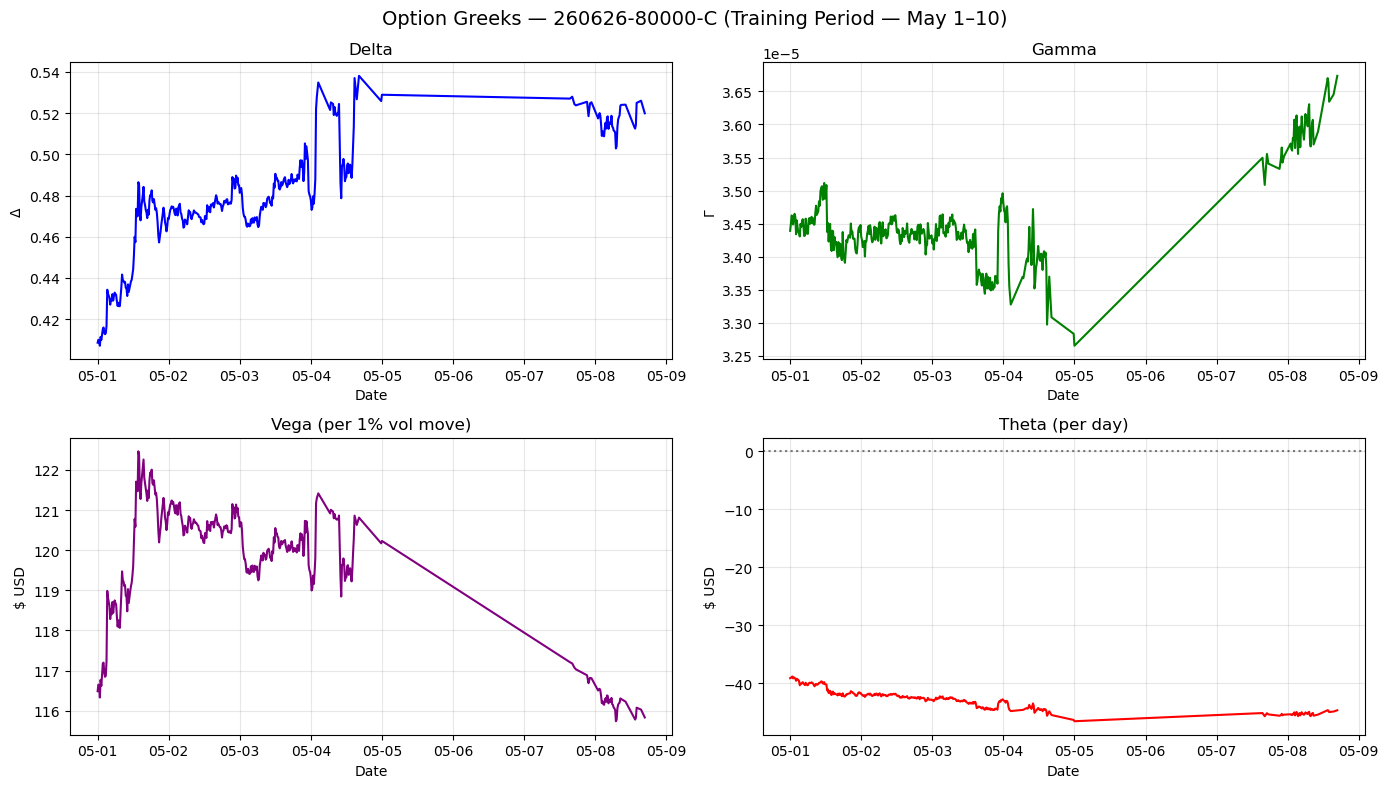

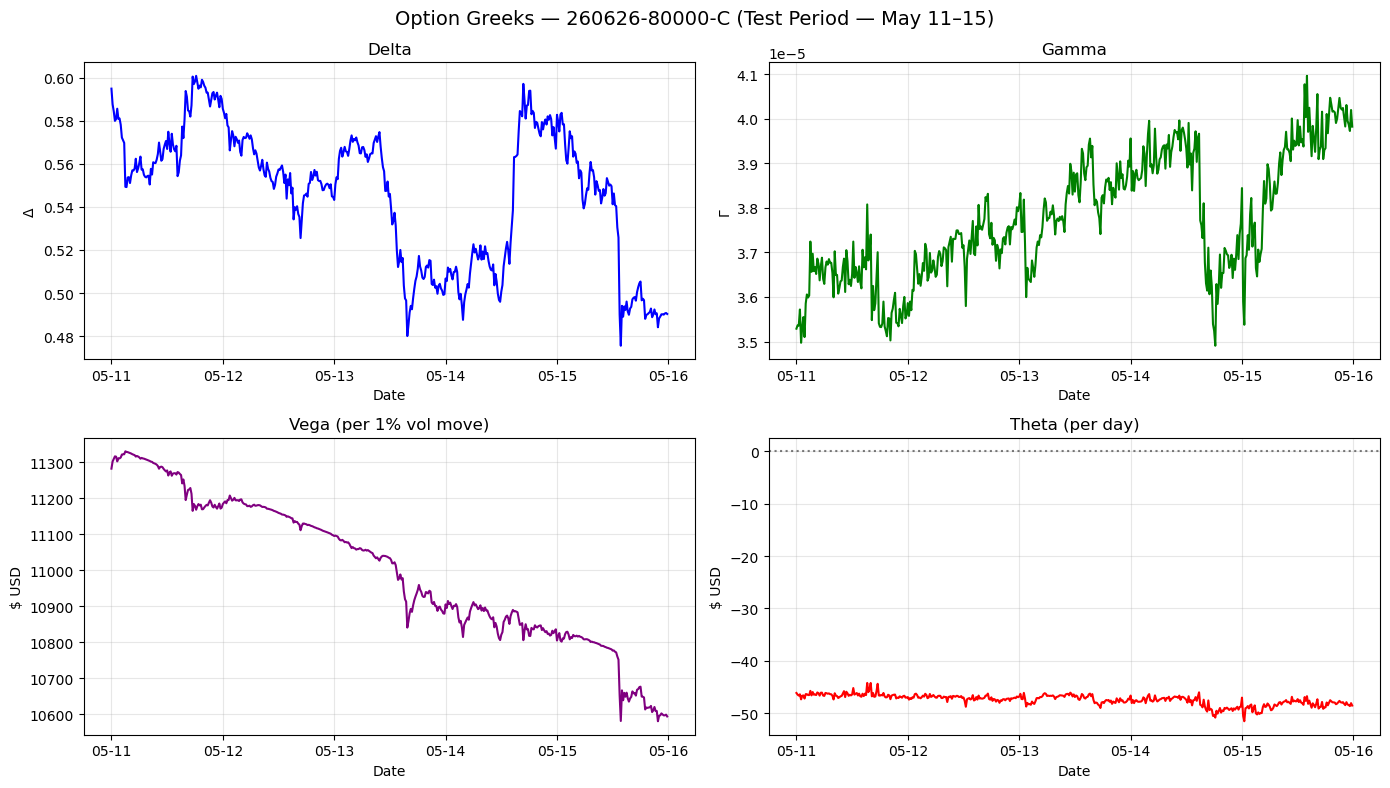

In [32]:
def plot_greeks(greeks_df, period_label):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Option Greeks — {EXPIRY}-{int(STRIKE)}-{CONTRACT_TYPE} ({period_label})', fontsize=14)

    axes[0,0].plot(greeks_df['datetime'], greeks_df['delta'], color='blue', linewidth=1.5)
    axes[0,0].set_title('Delta')
    axes[0,0].set_ylabel('Δ')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    axes[0,1].plot(greeks_df['datetime'], greeks_df['gamma'], color='green', linewidth=1.5)
    axes[0,1].set_title('Gamma')
    axes[0,1].set_ylabel('Γ')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    axes[1,0].plot(greeks_df['datetime'], greeks_df['vega'], color='purple', linewidth=1.5)
    axes[1,0].set_title('Vega (per 1% vol move)')
    axes[1,0].set_ylabel('$ USD')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    axes[1,1].plot(greeks_df['datetime'], greeks_df['theta'], color='red', linewidth=1.5)
    axes[1,1].set_title('Theta (per day)')
    axes[1,1].set_ylabel('$ USD')
    axes[1,1].axhline(0, color='black', linestyle=':', alpha=0.5)
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    for ax in axes.flatten():
        ax.set_xlabel('Date')

    plt.tight_layout()
    plt.show()


# Training period Greeks (May 1–10)
plot_greeks(greeks_train_df, 'Training Period — May 1–10')

# Test period Greeks (May 11–15)
plot_greeks(greeks_test_df, 'Test Period — May 11–15')

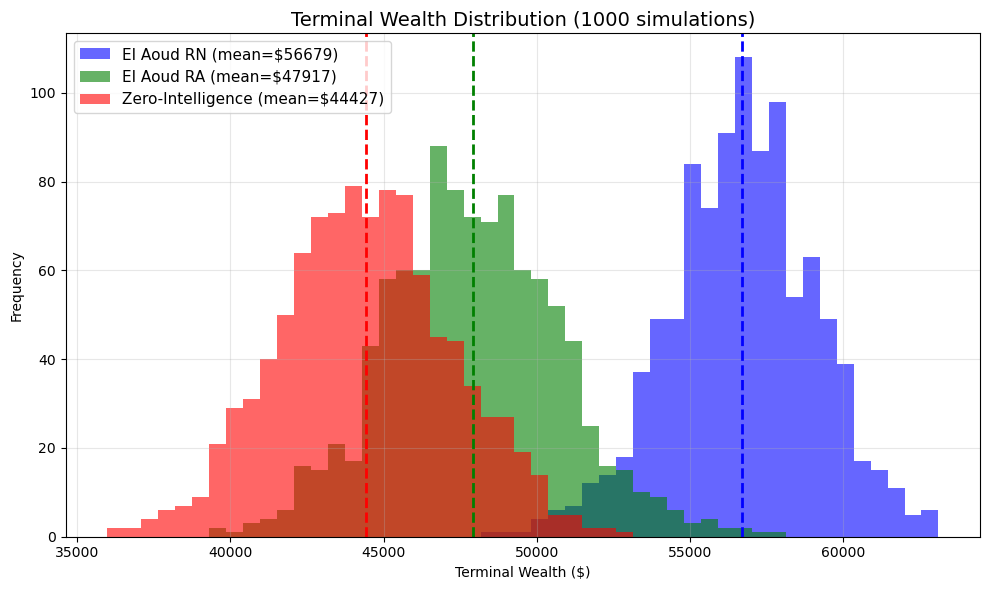

In [33]:
# ============================================================
# Viz 1 — Terminal Wealth Distribution
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(
    min(wealth_rn.min(), wealth_ra.min(), wealth_zi.min()),
    max(wealth_rn.max(), wealth_ra.max(), wealth_zi.max()),
    50
)

ax.hist(wealth_rn, bins=bins, alpha=0.6, color='blue',
        label=f'El Aoud RN (mean=${wealth_rn.mean():.0f})')
ax.hist(wealth_ra, bins=bins, alpha=0.6, color='green',
        label=f'El Aoud RA (mean=${wealth_ra.mean():.0f})')
ax.hist(wealth_zi, bins=bins, alpha=0.6, color='red',
        label=f'Zero-Intelligence (mean=${wealth_zi.mean():.0f})')

ax.axvline(wealth_rn.mean(), color='blue', linestyle='--', linewidth=2)
ax.axvline(wealth_ra.mean(), color='green', linestyle='--', linewidth=2)
ax.axvline(wealth_zi.mean(), color='red', linestyle='--', linewidth=2)

ax.set_title('Terminal Wealth Distribution (1000 simulations)', fontsize=14)
ax.set_xlabel('Terminal Wealth ($)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

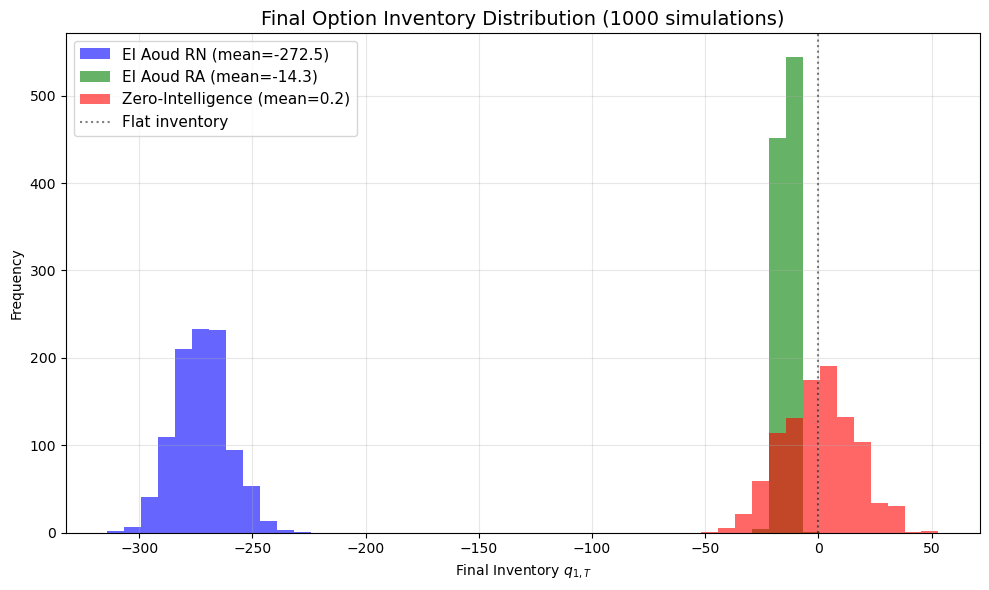

In [34]:
# ============================================================
# Viz 2 — Final Inventory Distribution
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

bins_inv = np.linspace(
    min(inv_rn.min(), inv_ra.min(), inv_zi.min()),
    max(inv_rn.max(), inv_ra.max(), inv_zi.max()),
    50
)

ax.hist(inv_rn, bins=bins_inv, alpha=0.6, color='blue',
        label=f'El Aoud RN (mean={inv_rn.mean():.1f})')
ax.hist(inv_ra, bins=bins_inv, alpha=0.6, color='green',
        label=f'El Aoud RA (mean={inv_ra.mean():.1f})')
ax.hist(inv_zi, bins=bins_inv, alpha=0.6, color='red',
        label=f'Zero-Intelligence (mean={inv_zi.mean():.1f})')

ax.axvline(0, color='black', linestyle=':', alpha=0.5,
           label='Flat inventory')
ax.set_title('Final Option Inventory Distribution (1000 simulations)',
             fontsize=14)
ax.set_xlabel('Final Inventory $q_{1,T}$')
ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

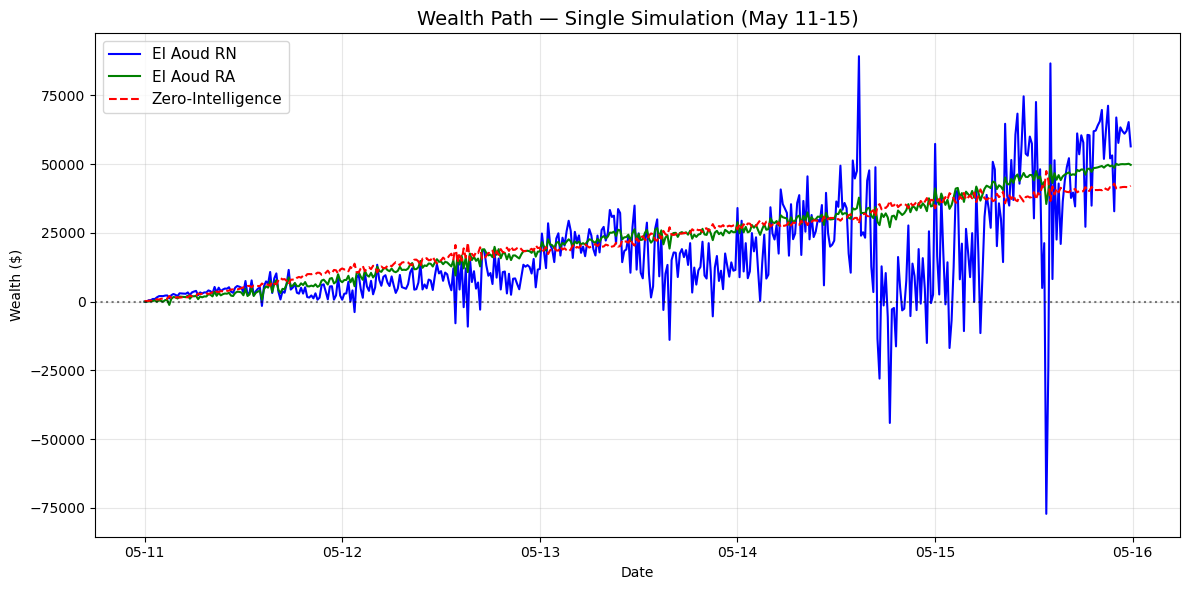

In [35]:
# ============================================================
# Viz 3 — Wealth Path (single simulation)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(path_rn['datetime'], path_rn['W'],
        color='blue', linewidth=1.5, label='El Aoud RN')
ax.plot(path_ra['datetime'], path_ra['W'],
        color='green', linewidth=1.5, label='El Aoud RA')
ax.plot(path_zi['datetime'], path_zi['W'],
        color='red', linewidth=1.5, linestyle='--',
        label='Zero-Intelligence')
ax.axhline(0, color='black', linestyle=':', alpha=0.5)

ax.set_title('Wealth Path — Single Simulation (May 11-15)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Wealth ($)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

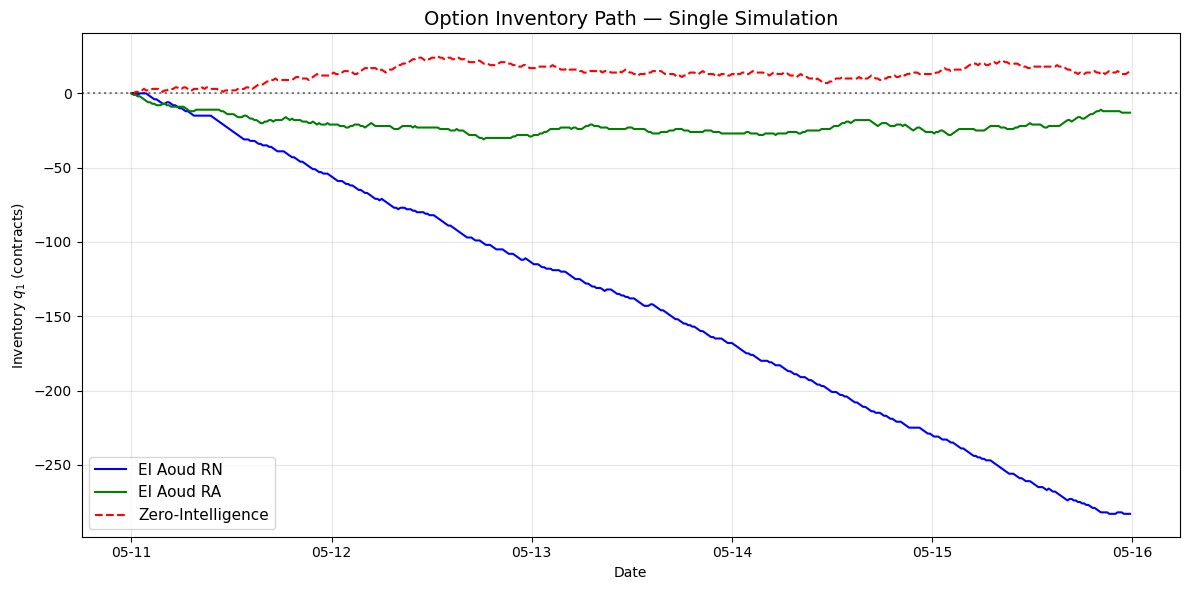

In [36]:
# ============================================================
# Viz 4 — Inventory Path (single simulation)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(path_rn['datetime'], path_rn['q1'],
        color='blue', linewidth=1.5, label='El Aoud RN')
ax.plot(path_ra['datetime'], path_ra['q1'],
        color='green', linewidth=1.5, label='El Aoud RA')
ax.plot(path_zi['datetime'], path_zi['q1'],
        color='red', linewidth=1.5, linestyle='--',
        label='Zero-Intelligence')
ax.axhline(0, color='black', linestyle=':', alpha=0.5)

ax.set_title('Option Inventory Path — Single Simulation', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Inventory $q_1$ (contracts)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

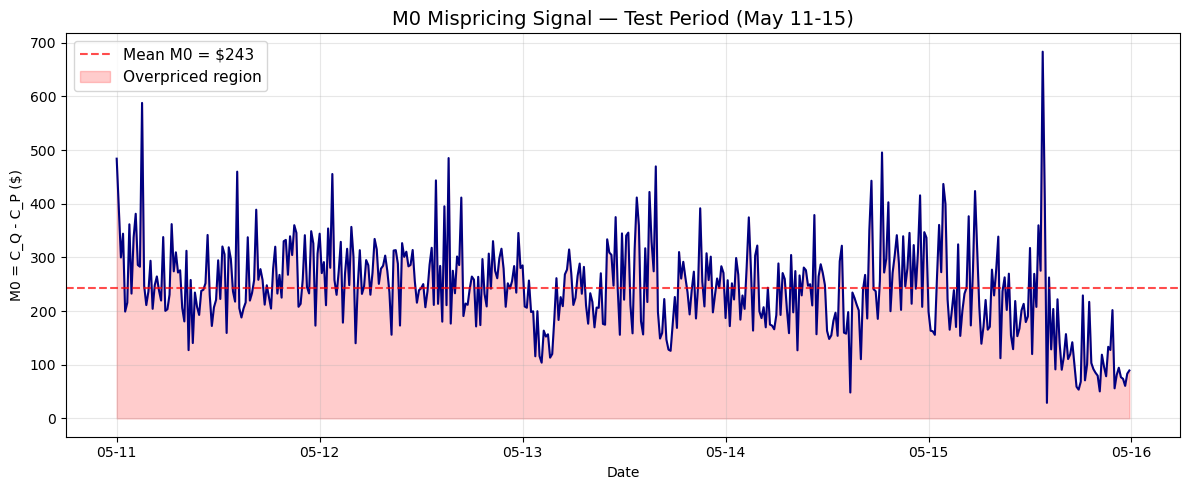

In [37]:
# ============================================================
# Viz 5 — M0 Signal Through Test Period
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(strategy_df['datetime'], strategy_df['M0'],
        color='navy', linewidth=1.5)
ax.axhline(strategy_df['M0'].mean(), color='red',
           linestyle='--', alpha=0.7,
           label=f"Mean M0 = ${strategy_df['M0'].mean():.0f}")
ax.fill_between(strategy_df['datetime'], strategy_df['M0'], 0,
                alpha=0.2, color='red', label='Overpriced region')

ax.set_title('M0 Mispricing Signal — Test Period (May 11-15)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('M0 = C_Q - C_P ($)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

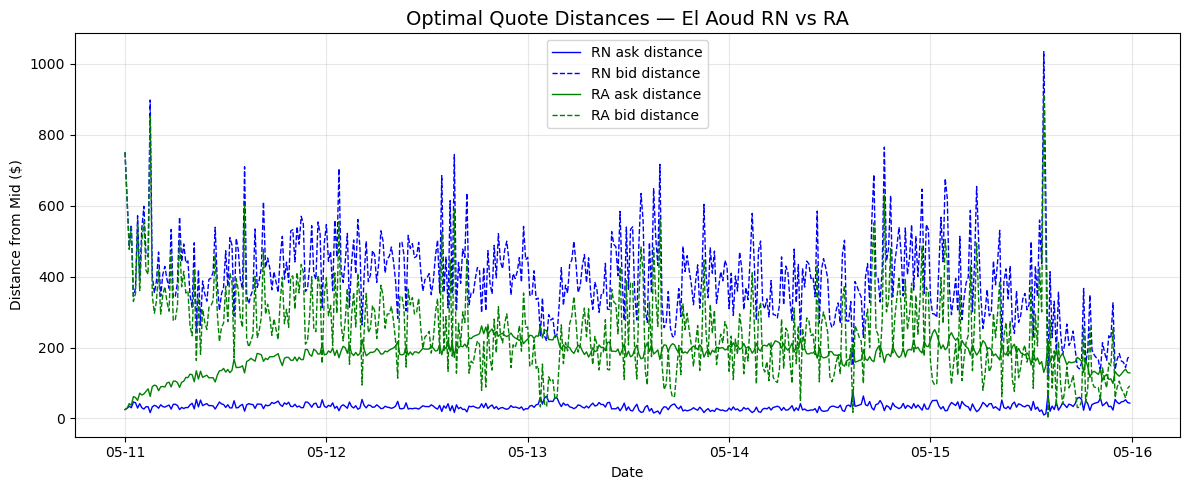

In [38]:
# ============================================================
# Viz 6 — Optimal Quote Distances Through Time
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(path_rn['datetime'], path_rn['delta_plus'],
        color='blue', linewidth=1.0, label='RN ask distance')
ax.plot(path_rn['datetime'], path_rn['delta_minus'],
        color='blue', linewidth=1.0, linestyle='--',
        label='RN bid distance')
ax.plot(path_ra['datetime'], path_ra['delta_plus'],
        color='green', linewidth=1.0, label='RA ask distance')
ax.plot(path_ra['datetime'], path_ra['delta_minus'],
        color='green', linewidth=1.0, linestyle='--',
        label='RA bid distance')

ax.set_title('Optimal Quote Distances — El Aoud RN vs RA', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Distance from Mid ($)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

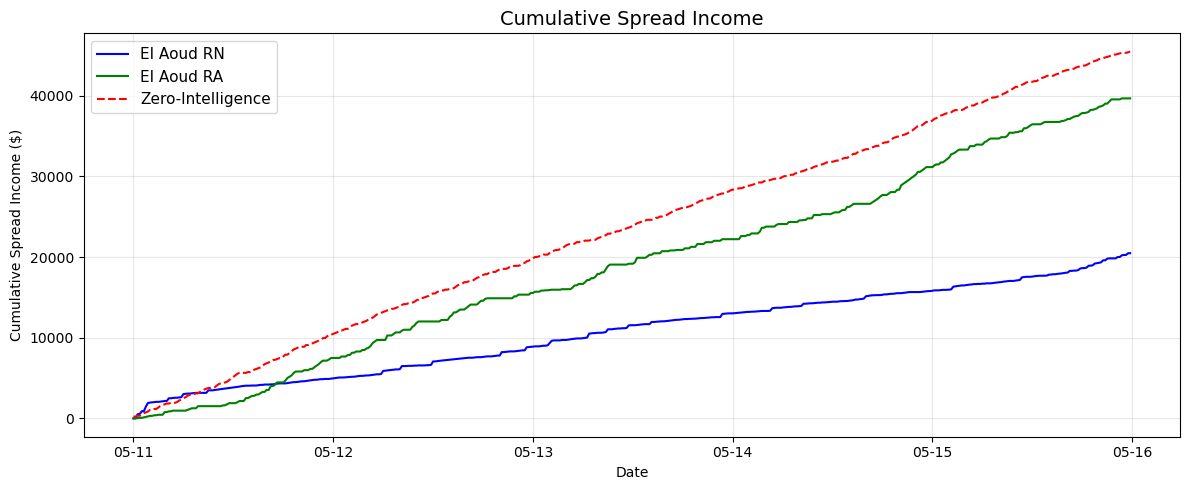

In [39]:
# ============================================================
# Viz 7 — Spread Income Cumulative
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(path_rn['datetime'],
        path_rn['spread_income'].cumsum(),
        color='blue', linewidth=1.5, label='El Aoud RN')
ax.plot(path_ra['datetime'],
        path_ra['spread_income'].cumsum(),
        color='green', linewidth=1.5, label='El Aoud RA')
ax.plot(path_zi['datetime'],
        path_zi['spread_income'].cumsum(),
        color='red', linewidth=1.5, linestyle='--',
        label='Zero-Intelligence')

ax.set_title('Cumulative Spread Income', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Spread Income ($)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.tight_layout()
plt.show()

In [40]:
# export El Aoud quotes for comparison
el_aoud_quote_df = strategy_df[['datetime', 'C_Q', 'M0']].copy()
el_aoud_quote_df['ea_dp'], el_aoud_quote_df['ea_dm'] = zip(*el_aoud_quote_df.apply(
    lambda r: el_aoud_quotes(M0=r['M0'], C_Q=r['C_Q'], B_param=lambda_params['B']),
    axis=1
))
el_aoud_quote_df['ea_ask'] = el_aoud_quote_df['C_Q'] + el_aoud_quote_df['ea_dp']
el_aoud_quote_df['ea_bid'] = el_aoud_quote_df['C_Q'] - el_aoud_quote_df['ea_dm']

el_aoud_quote_df.to_parquet('../../RandomData/el_aoud_quotes.parquet')
print(el_aoud_quote_df.head(5))

                 datetime         C_Q          M0      ea_dp       ea_dm  \
0 2026-05-11 00:00:00.002  5649.80970  483.932861  25.046578  750.945869   
1 2026-05-11 00:15:00.003  5452.14000  390.735107  28.499002  614.601663   
2 2026-05-11 00:30:00.003  5323.74750  299.888745  34.482283  484.315400   
3 2026-05-11 00:45:00.003  5274.59975  344.148116  30.011647  546.233820   
4 2026-05-11 01:00:00.003  5215.97440  199.103786  46.452118  345.107797   

        ea_ask       ea_bid  
0  5674.856278  4898.863831  
1  5480.639002  4837.538337  
2  5358.229783  4839.432100  
3  5304.611397  4728.365930  
4  5262.426518  4870.866603  
